## SHAP explainability

I added SHAP explainability because a health app that just says 'Avoid' without explanation isn't useful. SHAP gives 
  per-prediction explanations — users can see exactly which nutrients drove the classification, which builds trust and helps them make better     
  choices

In [1]:
import shap

/Users/chandramitadutta/Documents/Nutrisense/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import joblib

pipeline = joblib.load('../models/model.joblib')
le = joblib.load('../models/label_encoder.joblib') 

df = pd.read_csv('../data/processed/features_labeled.csv', low_memory=False)

In [3]:
X = df.drop(['product_name', 'categories', 'countries', 'nutriscore_score',
       'nutriscore_grade','category_top','health_label'], axis=1)

In [4]:
xgb_model = pipeline.named_steps['model']

Before we apply SHAP, we need to apply the preprocessing(scale) to X before passing it to SHAP, since XGBoost Model was trained on preprocessed data. We can get the preprocessed version by running X through all pipeline steps except the model.

In [5]:
X_processed = pipeline[:-1].transform(X)

#pipeline[:-1] means "all steps except the last one (the model)""

In [6]:
X_processed.shape

(333984, 32)

In [7]:
# Now we can create the SHAP explainer and compute SHAP values. Computing on 333k rows would be slow, so we'll use a sample:

X_sample = pd.DataFrame(X_processed, columns = X.columns).sample(1000,random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

  shap.TreeExplainer(xgb_model) — creates an explainer specifically designed for tree-based models. It uses an efficient algorithm to compute     
  exact SHAP values by traversing the tree structure. Much faster than the general explainer.
                                                                                                                                                  
  explainer.shap_values(X_sample) — computes SHAP values for each row in X_sample. For each food and each feature, it calculates: "how much did   
  this feature push the prediction away from the average prediction?"                                                                             
                                                                                                                                                  
  Positive value = pushed toward this class. Negative value = pushed away.                                                                        
                                                                                                                                                  
  Since we have 3 classes (Healthy/Moderate/Unhealthy), it returns one matrix per class — so the output is a list of 3 matrices, each of shape    
  (1000 rows × 32 features). 

In [8]:
type(shap_values)

numpy.ndarray

In [9]:
len(shap_values)

1000

In [10]:
shap_values.shape

(1000, 32, 3)

Now let's plot the global feature importance — which features matter most overall for the Unhealthy class: 

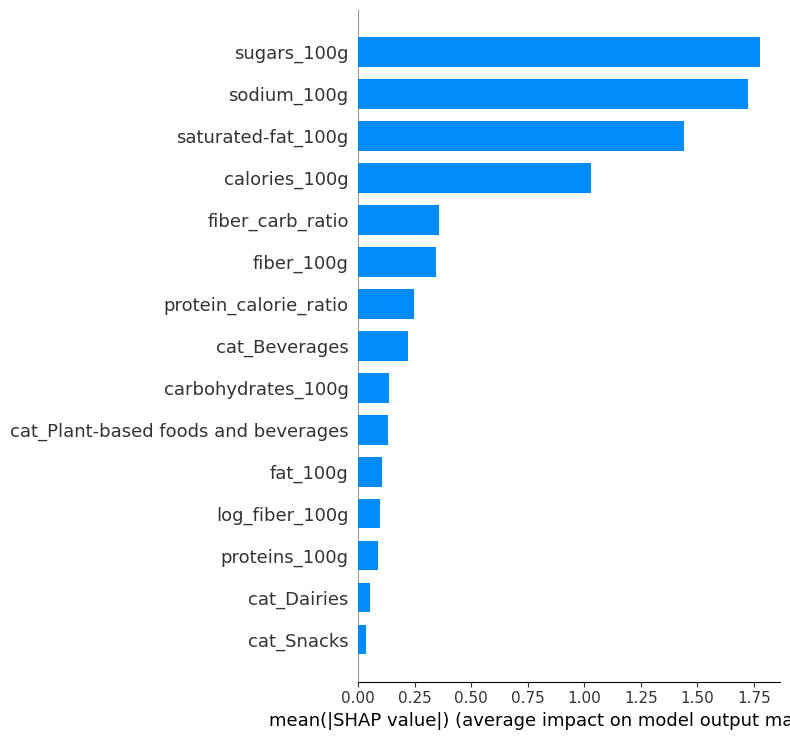

In [11]:
shap.summary_plot(shap_values[:, :, 2], X_sample, plot_type = 'bar', max_display=15)

The SHAP summary plot showed sugar and category features like Beverages among the top predictors of Unhealthy 
  classification — confirming the model learned nutritionally meaningful signals rather than spurious correlations.

Now let's do a per-prediction waterfall plot — showing why the model classified one specific food the way it did-

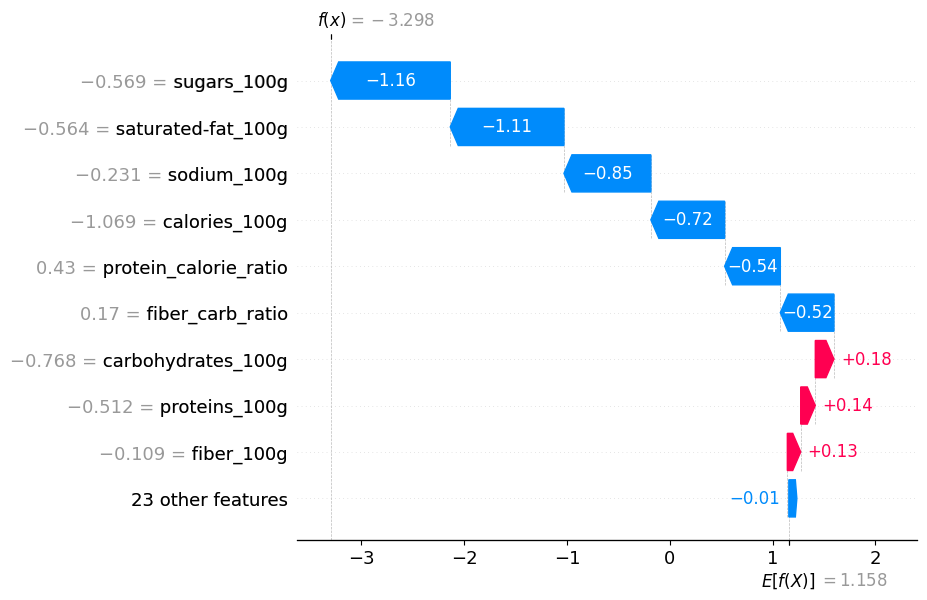

In [12]:
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0,:,2],
    base_values = explainer.expected_value[2],
    data=X_sample.iloc[0],
    feature_names = X_sample.columns.tolist()
))

# Observation:
Starting point — E[f(X)] = 1.158 (bottom right)
  This is the baseline — the average Unhealthy score across all foods. Every prediction starts here.

  Each bar moves the score left (blue) or right (red):

  - sugars_100g = -0.569 → contributes -1.16 — this food has low sugar, strongly pushes away from Unhealthy.  A SHAP value of -1.16 for sugars_100g means: "this food's sugar level pushed the Unhealthy score down by 1.16 units from the baseline — meaning low sugar is making the model less likely to classify this food as 
  Unhealthy." 
  - saturated-fat_100g = -0.564 → contributes -1.11 — low saturated fat, pushes away from Unhealthy
  - sodium_100g = -0.231 → contributes -0.85 — low sodium, pushes away
  - calories_100g = -1.069 → contributes -0.72 — low calories, pushes away
  - protein_calorie_ratio = 0.43 → contributes -0.54 — pushes away
  - fiber_carb_ratio = 0.17 → contributes -0.52 — pushes away
  - carbohydrates_100g = -0.768 → contributes +0.18 — slightly pushes toward Unhealthy
  - proteins_100g = -0.512 → contributes +0.14 — slightly pushes toward Unhealthy
  - fiber_100g = -0.109 → contributes +0.13 — slightly pushes toward Unhealthy

  Final score — f(x) = -3.298 (top)
  After all pushes, the Unhealthy score is -3.298 — far below baseline. This food is almost certainly not Unhealthy.

  The left column shows the feature values for this specific food — e.g. sugars_100g = -0.569 means this food's sugar value is 0.569 standard deviations below the mean
  (remember we scaled the data).
  

In [13]:
# Now lets check the actual predicted class
le.inverse_transform(pipeline.predict(pd.DataFrame([X.iloc[0]])))[0] 

'Healthy'

This is consistent with the waterfall plot. The Unhealthy score was -3.298 (far below baseline), which means the model was very confident this food is not Unhealthy. And   
  indeed it predicted Healthy.                                                                                                                                                  
                                                                                                                                                                                
  The SHAP explanation tells us exactly why — low sugar, low saturated fat, low sodium, and low calories all pushed strongly away from Unhealthy.